# Example: Stoichiometric Structure and Singular Value Decomposition
Which metabolite balances are independent, and which combinations of reaction fluxes satisfy steady-state balance? We will use singular value decomposition (SVD) to answer these questions for a metabolic network.

> __Learning Objectives:__
>
> By the end of this example, you should be able to:
>
> * __Construct and decompose a stoichiometric matrix:__ Assemble the matrix from metabolite and reaction records, compute its full SVD, and determine its numerical rank.
> * __Identify conservation relations:__ Extract the left nullspace and explain which weighted metabolite sums the modeled reactions conserve.
> * __Identify balanced flux combinations:__ Extract the right nullspace and distinguish steady-state balance from feasibility under reaction bounds.

In this example, we will use a cached BiGG model of human platelet metabolism. We will build its stoichiometric matrix, examine its singular values and matrix approximations, and interpret the two nullspaces in the context of metabolic modeling.

___

## Setup, Data, and Prerequisites
First, we load the local [`Include.jl`](Include.jl) setup file and its required packages.

> __Include:__ The [`include(...)` command](https://docs.julialang.org/en/v1/base/#include) evaluates [`Include.jl`](Include.jl) in the notebook's global scope. The setup file activates the course project, defines local paths, and loads the packages and local functions used here.

Let's set up our code environment:

In [1]:
include(joinpath(@__DIR__, "Include.jl")); # load the local notebook setup

# Choose a plot theme; rerun this cell and the plotting cells after changing it -
theme(:default); # light background
# theme(:dark); # dark background

See the [Julia documentation](https://docs.julialang.org/en/v1/) and the [course package documentation](https://varnerlab.github.io/VLDataScienceMachineLearningPackage.jl/dev/) for the functions and types used here.

___

## Task 1: Construct the stoichiometric matrix
In this task, we will load a metabolic reconstruction, inspect its metabolite and reaction records, and assemble the stoichiometric matrix. The matrix connects the biological records to the linear algebra used in the next task.

We will use the human platelet model `iAT_PLT_636` from [BiGG Models](http://bigg.ucsd.edu/), described by [Thomas et al. (2014)](https://pubmed.ncbi.nlm.nih.gov/24473230/). The supplied model contains 738 metabolites and 1008 reactions. The code loads the saved model when available; otherwise, it downloads the selected model and caches it for later use.

In [2]:
model = let

    # Select the model and cache file -
    baseurl = "http://bigg.ucsd.edu"; # base url to download model
    modelid = "iAT_PLT_636"; # BiGG identifier; changing it selects a different cache file
    path_to_saved_model_file = joinpath(CHEME5800_L7B_DATA, "saved-model-$(modelid).jld2");

    # Download only when the local cache is absent -
    model = nothing;
    if (isfile(path_to_saved_model_file) == false)
        
        endpoint = MyBiggModelsDownloadModelEndpointModel();
        endpoint.bigg_id = modelid;
        url = build(baseurl, endpoint)
        model = MyBiggModelsDownloadModelEndpointModel(url);

        # Cache the model for subsequent runs -
        save(path_to_saved_model_file, Dict("model" => model));
    else
        model = load(path_to_saved_model_file)["model"];
    end
    model; # return the model (either saved, or downloaded)
end;

__Metabolite records.__ Each metabolite has an identifier, a name, and a compartment. The identifier lets us match the metabolite to its coefficients in the reaction records. Let's inspect the second metabolite:

In [3]:
let
    metabolite = model["metabolites"][2]; # choose a record to inspect
    (id = metabolite["id"], name = metabolite["name"], compartment = metabolite["compartment"])
end

(id = "h2o_c", name = "H2O H2O", compartment = "c")

__Reaction records.__ A reaction's `metabolites` field maps metabolite identifiers to stoichiometric coefficients. Let's identify the sixth reaction and inspect that field:

In [4]:
let
    reaction = model["reactions"][6]; # choose a reaction to inspect
    (id = reaction["id"], name = reaction["name"])
end

(id = "PIPLC_18_0_20_4", name = "PIPLC 18 0 20 4")

In [5]:
model["reactions"][6]["metabolites"] # metabolite identifiers and net stoichiometric coefficients

JSON.Object{String, Any} with 5 entries:
  "dag_hs_18_0_20_4_c"  => 1.0
  "h2o_c"               => -1.0
  "h_c"                 => 1.0
  "mi1p__D_c"           => 1.0
  "pail_hs_18_0_20_4_c" => -1.0

Positive coefficients record net production; negative coefficients record net consumption. A zero coefficient means no net change, including when a species appears on both sides and cancels.

__Matrix construction.__ We place metabolites on the rows and reactions on the columns. For $m$ metabolites and $n$ reactions, the matrix is given by:

$$
\mathbf{S}=[\sigma_{ij}]\in\mathbb{R}^{m\times n}.
$$

The outer loop selects a metabolite identifier; the inner loop looks up its coefficient in each reaction. Entries remain zero when the identifier is absent.

In [6]:
S = let

    # Read the records and allocate the matrix -
    metabolites = model["metabolites"]; # row order
    reactions = model["reactions"]; # column order
    number_of_metabolites = length(metabolites);
    number_of_reactions = length(reactions);
    S = zeros(number_of_metabolites, number_of_reactions);

    # Match each metabolite identifier to its reaction coefficients -
    for i ∈ eachindex(metabolites)
        metabolite_id = metabolites[i]["id"];
        for j ∈ eachindex(reactions)
            coefficients = reactions[j]["metabolites"];
            if haskey(coefficients, metabolite_id)
                S[i, j] = coefficients[metabolite_id];
            end
        end
    end
    S;
end;

Let's check the matrix dimensions using [the `size(...)` function](https://docs.julialang.org/en/v1/base/arrays/#Base.size):

In [7]:
size(S) # (number of metabolites, number of reactions)

(738, 1008)

For the supplied platelet model, the matrix has 738 rows and 1008 columns. There are more reaction fluxes than metabolite balances, so stoichiometric balance alone cannot determine every flux uniquely. Next, we will use the SVD to determine how many balances are independent and examine the matrix's remaining degrees of freedom.

___

## Task 2: Compute and interpret the singular value decomposition
In this task, we will compute the full SVD, determine the numerical rank, and examine how well a limited number of modes reconstructs the stoichiometric matrix.

For $m$ metabolites and $n$ reactions, the full decomposition is given by:

$$
\mathbf{S}=\mathbf{U}\boldsymbol{\Sigma}\mathbf{V}^{\top}.
$$

The matrix dimensions are:

$$
\mathbf{S}\in\mathbb{R}^{m\times n},\qquad
\mathbf{U}\in\mathbb{R}^{m\times m},\qquad
\boldsymbol{\Sigma}\in\mathbb{R}^{m\times n},\qquad
\mathbf{V}\in\mathbb{R}^{n\times n}.
$$

The columns of $\mathbf{U}$ and $\mathbf{V}$ are orthonormal bases for metabolite and reaction space, respectively. __Orthonormal__ means that each column has unit length and distinct columns have zero inner product. For the full, square matrices used here, these properties give:

$$
\begin{aligned}
\mathbf{U}^{\top}\mathbf{U}=\mathbf{U}\mathbf{U}^{\top}&=\mathbf{I}_m,\\
\mathbf{V}^{\top}\mathbf{V}=\mathbf{V}\mathbf{V}^{\top}&=\mathbf{I}_n,
\end{aligned}
$$

where $\mathbf{I}_m$ and $\mathbf{I}_n$ are identity matrices of sizes $m\times m$ and $n\times n$.

The rectangular diagonal matrix $\boldsymbol{\Sigma}$ holds the singular values in descending order. Julia returns these values as a vector named `Σ`; we do not need to form the rectangular matrix.

We use [the `svd(...)` function](https://docs.julialang.org/en/v1/stdlib/LinearAlgebra/#LinearAlgebra.svd) with `full=true` to retain the complete bases needed for the nullspaces in Task 3:

In [8]:
U, Σ, V = svd(S; alg=LinearAlgebra.QRIteration(), full=true);
(size_S = size(S), size_U = size(U), size_V = size(V), singular_values = length(Σ))

(size_S = (738, 1008), size_U = (738, 738), size_V = (1008, 1008), singular_values = 738)

For the supplied model, $\mathbf{U}$ is $738\times738$, $\mathbf{V}$ is $1008\times1008$, and the vector contains 738 singular values. The extra columns of the full $\mathbf{V}$ are needed to span the complete right nullspace.

### Numerical rank and conditioning
In exact arithmetic, the rank of $\mathbf{S}$ is the number of nonzero singular values. In a floating-point calculation, rounding can turn a zero singular value into a small nonzero value. We therefore estimate the rank by counting singular values above a tolerance:

$$
\tau=\epsilon\max(m,n)\sigma_1,
\qquad
r=\#\{i:\sigma_i>\tau\}.
$$

Here, $\epsilon\approx2.22\times10^{-16}$ is the spacing between $1.0$ and the next larger `Float64` value. It characterizes the precision of the arithmetic. The factors $\max(m,n)$ and $\sigma_1$ adjust the cutoff for the matrix dimensions and scale.

We treat singular values at or below $\tau$ as zero. The resulting __numerical rank__ $r$ estimates the number of independent rows or columns; the corresponding left and right nullspace dimensions are $m-r$ and $n-r$.

In [9]:
m, n = size(S); # numbers of metabolites and reactions
τ = eps(Float64) * max(m, n) * Σ[1]; # tolerance scaled to the matrix dimensions and largest singular value
r = count(σ -> σ > τ, Σ); # numerical rank
(rank = r, left_nullity = m-r, right_nullity = n-r)

(rank = 719, left_nullity = 19, right_nullity = 289)

For the platelet matrix, $\tau\approx9.45\times10^{-12}$ gives a numerical rank of 719: there are 19 dependent balance directions and 289 independent directions in the balanced-flux space. We will interpret these nullspaces in Task 3.

For a rank-deficient matrix, the usual singular-value condition number is unbounded in exact arithmetic. We can instead examine the spread of the retained, nonzero singular values:

$$
\kappa_{\mathrm{retained}}=\frac{\sigma_1}{\sigma_r}.
$$

This ratio describes conditioning on the retained singular subspace; it does not remove the rank deficiency.

In [10]:
κ_retained = r > 0 ? Σ[1] / Σ[r] : missing; # undefined if the matrix has numerical rank zero
κ_retained

1307.2069939575724

The retained-spectrum ratio is about 1307 for this model.

### How much does each mode contribute?
Each singular triplet satisfies $\mathbf{S}\mathbf{v}_i=\sigma_i\mathbf{u}_i$. Thus, a weighted reaction combination $\mathbf{v}_i$ maps to a metabolite production pattern $\sigma_i\mathbf{u}_i$. Keeping the first $k$ triplets gives the rank-$k$ approximation:

$$
\mathbf{S}_k=\sum_{i=1}^{k}\sigma_i\mathbf{u}_i\mathbf{v}_i^{\top}.
$$

For a nonzero matrix, we measure the fraction retained using the squared Frobenius norm, which is the sum of squared matrix entries:

$$
F_k=\frac{\sum_{i=1}^{k}\sigma_i^2}{\sum_{i=1}^{\min(m,n)}\sigma_i^2},
\qquad
\frac{\|\mathbf{S}-\mathbf{S}_k\|_F}{\|\mathbf{S}\|_F}=\sqrt{1-F_k}.
$$

This measures matrix reconstruction, not the fraction of biological activity explained. Let's plot the retained fraction against the number of modes:

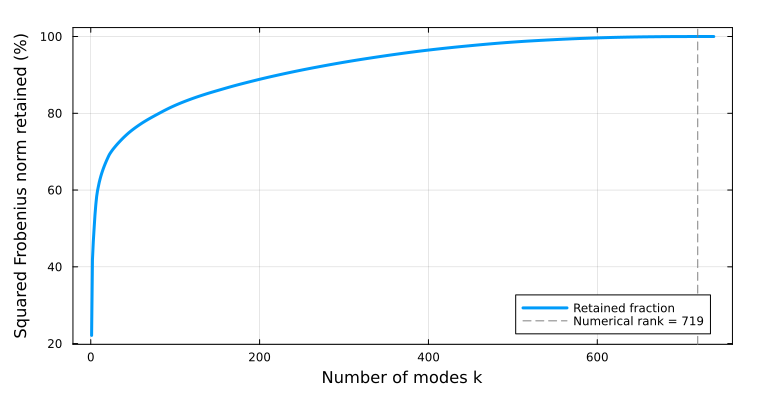

In [11]:
retained_fraction = cumsum(abs2.(Σ)) / sum(abs2, Σ); # cumulative fraction of the squared Frobenius norm
let
    p = plot(eachindex(Σ), 100 .* retained_fraction;
        xlabel="Number of modes k", ylabel="Squared Frobenius norm retained (%)",
        label="Retained fraction", linewidth=3, legend=:bottomright,
        framestyle=:box, size=(760, 400), margin=5Plots.mm);
    vline!(p, [r]; label="Numerical rank = $(r)", linestyle=:dash, color=:gray);
    p;
end

The curve approaches 100% by the numerical rank; the remaining singular values are negligible at our tolerance. Large singular values contribute more to the reconstruction, but their size alone does not establish biological importance.

Let's reconstruct the matrix using at most 400 modes. Matrix multiplication computes the sum directly, avoiding storage of every rank-one component:

In [12]:
k = min(400, r); # number of retained modes; change this to compare approximations
S_k = U[:, 1:k] * Diagonal(Σ[1:k]) * transpose(V[:, 1:k]);
relative_error = norm(S - S_k) / norm(S); # matrix norm here is the Frobenius norm
(modes = k, retained_percent = 100 * retained_fraction[k], relative_error = relative_error)

(modes = 400, retained_percent = 96.47078952538439, relative_error = 0.18786193000753681)

For the supplied model, 400 modes retain about 96.47% of the squared norm, with a relative reconstruction error of about 18.79%. These values change with the model and selected mode count.

### View the cumulative reconstruction
The grayscale image below shows the full matrix $\mathbf{S}_k$, formed by adding the first $k$ weighted rank-one modes. Rows represent metabolites and columns represent reactions. Change `k` in the preceding cell and rerun these cells to see how the image develops as more modes are included.

We use black for coefficients below $-0.05$, gray for coefficients between $-0.05$ and $0.05$, and white for coefficients above $0.05$. This display threshold keeps small reconstruction artifacts from dominating the image; it does not change $\mathbf{S}_k$ or the numerical-rank tolerance.

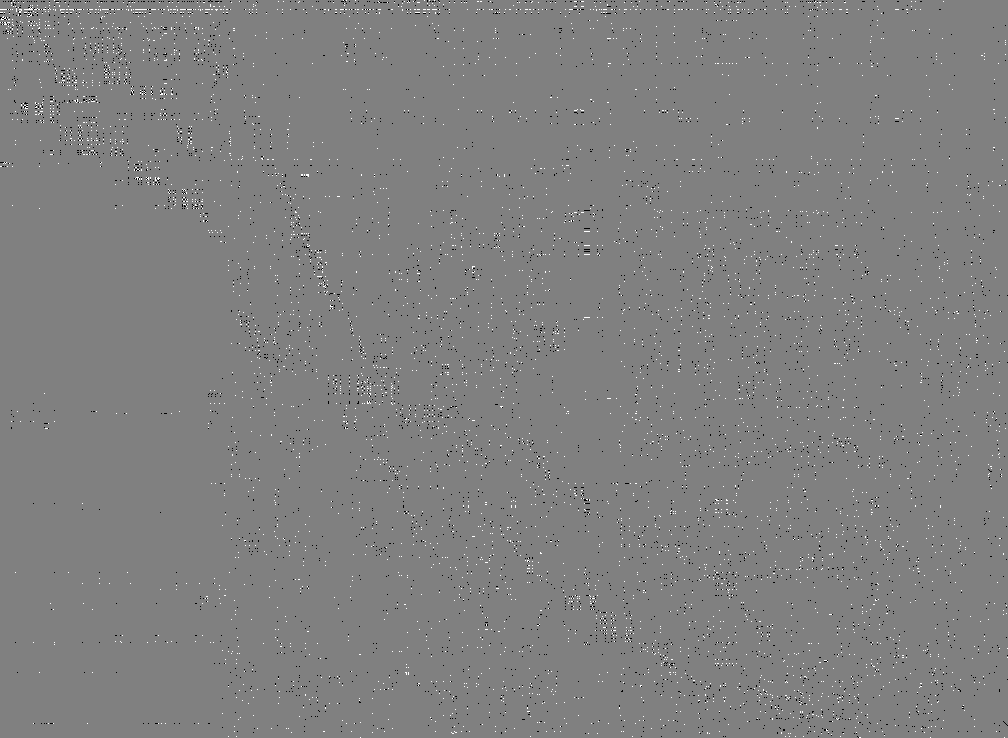

In [13]:
display_threshold = 0.05; # near-zero band for both images; independent of the rank tolerance
cumulative_image = Gray.(ifelse.(S_k .< -display_threshold, 0.0,
    ifelse.(S_k .> display_threshold, 1.0, 0.5))) # cumulative contribution of modes 1 through k

For comparison, the next image shows the original stoichiometric matrix using the same row order, column order, and grayscale thresholds. Compare the locations of the dark and light entries as you increase `k`:

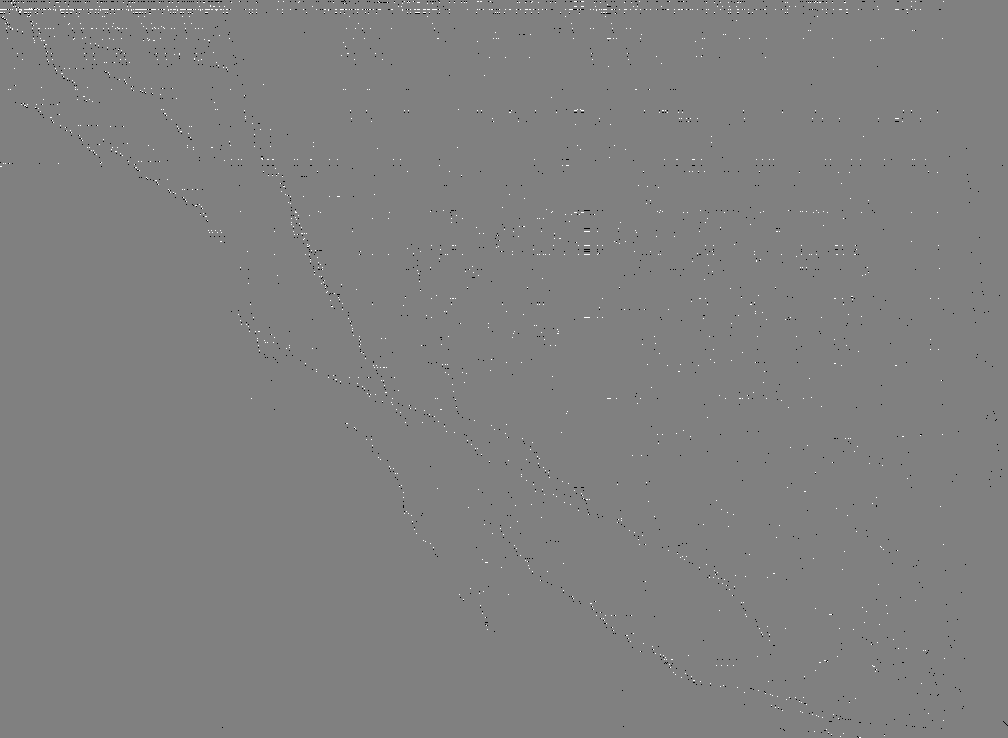

In [14]:
original_image = Gray.(ifelse.(S .< -display_threshold, 0.0,
    ifelse.(S .> display_threshold, 1.0, 0.5))) # full stoichiometric matrix

As more modes are included, the cumulative reconstruction approaches the original matrix. Truncation can introduce nonzero coefficients where the original has zeros, and the grayscale thresholds can hide small differences. The relative reconstruction error quantifies those differences using every matrix entry.

The approximation helps us examine matrix structure; it is not a replacement reaction network with chemically valid stoichiometry. Next, we will use the full singular-vector bases to extract conservation relations and balanced-flux directions.

___

## Task 3: Identify conservation relations and balanced-flux directions
In this task, we will extract the left and right nullspaces of $\mathbf{S}$, interpret their coefficients, and check whether a balanced flux vector satisfies the model's reaction bounds.

### Conservation relations from the left nullspace
The last $m-r$ columns of the full matrix $\mathbf{U}$ span the left nullspace. Collect these columns in $\mathbf{U}_0\in\mathbb{R}^{m\times(m-r)}$. They satisfy:

$$
\mathbf{S}^{\top}\mathbf{U}_0=\mathbf{0}.
$$

Why does this imply conservation? Let $\mathbf{x}(t)$ contain the metabolite amounts, with dynamics $d\mathbf{x}/dt=\mathbf{S}\mathbf{v}(t)$ accounting for all modeled reactions and transfers. For any weight vector $\mathbf{w}=\mathbf{U}_0\mathbf{a}$, where $\mathbf{a}\in\mathbb{R}^{m-r}$ selects a linear combination of the basis columns, we obtain:

$$
\frac{d}{dt}\left(\mathbf{w}^{\top}\mathbf{x}\right)
=\mathbf{w}^{\top}\mathbf{S}\mathbf{v}=0.
$$

Thus, the weighted sum $\mathbf{w}^{\top}\mathbf{x}(t)$ remains constant under these dynamics. An additional source or sink not included in $\mathbf{S}$ can break the relation.

Let's extract the basis using the numerical rank from Task 2 and check the largest absolute entry of $\mathbf{S}^{\top}\mathbf{U}_0$. The exact equalities above hold approximately in our floating-point calculation:

In [15]:
U0 = U[:, (r+1):m]; # basis for the left nullspace
left_residual = maximum(abs, transpose(S) * U0);
@assert left_residual < τ "Left-nullspace residual exceeds the rank tolerance."
(conservation_relations = size(U0, 2), largest_residual = left_residual)

(conservation_relations = 19, largest_residual = 2.0747292772682613e-15)

The model has 19 independent conservation relations. To inspect one basis vector, we show its 12 largest coefficients in magnitude. The complete vector remains in `U0`; the shortened table is only for display:

In [16]:
let
    relation_index = 3; # column of U0 to inspect
    weights = U0[:, relation_index];
    rows = sortperm(abs.(weights); rev=true)[1:min(12, m)];
    DataFrame(
        Metabolite = [model["metabolites"][i]["id"] for i in rows],
        Coefficient = round.(weights[rows]; digits=4),
    )
end

Row,Metabolite,Coefficient
,String,Float64
1,nadh_c,0.242
2,nad_c,0.242
3,nmn_c,0.242
4,rnam_c,0.242
5,ncam_c,0.242
6,nadp_m,-0.2001
7,nadph_m,-0.2001
8,nad_m,0.1604
9,nadh_m,0.1604


A basis vector can mix several conserved metabolite pools. Its sign and its orientation within the nullspace are not unique, so one column need not correspond to a single biochemical pool. The conservation relation uses the full vector, including entries omitted from the table.

### Balanced-flux directions from the right nullspace
The last $n-r$ columns of the full matrix $\mathbf{V}$ span the right nullspace. Collect them in $\mathbf{V}_0\in\mathbb{R}^{n\times(n-r)}$. Every balanced flux vector can be written as a linear combination of these columns:

$$
\mathbf{v}=\mathbf{V}_0\mathbf{a},
\qquad
\mathbf{S}\mathbf{v}=\mathbf{S}\mathbf{V}_0\mathbf{a}=\mathbf{0},
$$

where $\mathbf{a}\in\mathbb{R}^{n-r}$ contains the combination coefficients. This describes fluxes with no net accumulation of the metabolites represented by the rows of $\mathbf{S}$.

Let's extract the complete basis and check its mass-balance residual:

In [17]:
V0 = V[:, (r+1):n]; # basis for the right nullspace, including the extra columns of full V
right_residual = maximum(abs, S * V0);
@assert right_residual < τ "Right-nullspace residual exceeds the rank tolerance."
(balanced_flux_directions = size(V0, 2), largest_residual = right_residual)

(balanced_flux_directions = 289, largest_residual = 3.0531133177191805e-15)

The model has 289 independent balanced-flux directions. Let's inspect the 12 largest coefficients in column 10. Positive and negative coefficients indicate directions relative to each reaction's stored orientation:

In [18]:
flux_direction_index = 10; # column of V0 to inspect
let
    direction = V0[:, flux_direction_index];
    rows = sortperm(abs.(direction); rev=true)[1:min(12, n)];
    DataFrame(
        Reaction = [model["reactions"][j]["id"] for j in rows],
        Coefficient = round.(direction[rows]; digits=4),
    )
end

Row,Reaction,Coefficient
,String,Float64
1,VALtec,-0.1587
2,PI345P3P_18_1_18_1,-0.1492
3,URIt5,0.1427
4,PI4P5K_18_1_18_1,-0.1301
5,O2Stm,-0.13
6,DAGK_hs_18_2_18_2,0.1166
7,FATP2t,0.1148
8,PPA,0.1127
9,CEPTC_18_1_18_2,0.1075


### Does mass balance imply a feasible flux?
Mass balance alone does not enforce reaction direction or capacity. A feasible flux must also satisfy the model's lower and upper reaction bounds, $\mathbf{v}^{L}$ and $\mathbf{v}^{U}$. In nullspace coordinates, these constraints become:

$$
\mathbf{v}^{L}\leq\mathbf{V}_0\mathbf{a}\leq\mathbf{v}^{U}.
$$

As a concrete check, take column 10 as a trial flux vector, with combination coefficient 1 in the model's flux units. We check all reactions, including those omitted from the table:

In [19]:
v_trial = copy(V0[:, flux_direction_index]); # one particular balanced flux vector
lower_bounds = [reaction["lower_bound"] for reaction in model["reactions"]];
upper_bounds = [reaction["upper_bound"] for reaction in model["reactions"]];
bound_tolerance = 1e-8; # tolerance for the bound comparison in model flux units
violations = findall((v_trial .< lower_bounds .- bound_tolerance) .|
                    (v_trial .> upper_bounds .+ bound_tolerance));
(balance_residual = maximum(abs, S * v_trial),
 violated_bounds = length(violations), satisfies_bounds = isempty(violations))

(balance_residual = 1.5855372570428017e-15, violated_bounds = 271, satisfies_bounds = false)

The trial vector satisfies mass balance to numerical precision but violates reaction bounds. It is therefore not a feasible flux distribution for this model. A different combination of nullspace vectors may satisfy the bounds; the failed trial does not establish that the model is infeasible.

The singular value decomposition describes all balanced-flux directions. Flux balance analysis adds bounds and an objective to select a feasible flux distribution from this space.

___

## Summary
We constructed the platelet stoichiometric matrix, examined its singular values and cumulative reconstructions, and used its nullspaces to identify conservation relations and balanced-flux directions.

> __Key Takeaways:__
>
> * __Rank determines the nullspace dimensions:__ For an $m\times n$ matrix with numerical rank $r$, the left and right nullspaces have dimensions $m-r$ and $n-r$ at the chosen tolerance. Retaining fewer singular modes gives a matrix approximation whose error we can quantify.
> * __The left nullspace identifies conserved quantities:__ A weight vector $\mathbf{w}$ satisfying $\mathbf{S}^{\top}\mathbf{w}=\mathbf{0}$ defines a constant weighted metabolite sum $\mathbf{w}^{\top}\mathbf{x}$ under the modeled dynamics. Individual basis vectors can mix several biochemical pools.
> * __The right nullspace describes balanced fluxes:__ Every vector $\mathbf{v}=\mathbf{V}_0\mathbf{a}$ satisfies $\mathbf{S}\mathbf{v}=\mathbf{0}$, to numerical precision. Reaction bounds further restrict which combinations are feasible.

Stoichiometry establishes the balance constraints; reaction bounds and an objective turn those constraints into a flux balance optimization problem.

___
